# Group 91 — MAB Assignment: Adaptive Treatment Recommendation System

**Part #1 — Multi-Armed Bandit (MAB)**  
**Course:** Deep Reinforcement Learning  
**Total Marks:** 5  

---

### Team Contribution Plan
| Member | Responsibility |
|--------|----------------|
| Member 1 | Task 1 — Dataset Design and Environment Setup |
| Member 2 | Task 2 — Immediate Exploitation (Greedy) Strategy |
| Member 3 | Task 3 — Epsilon-Greedy Controlled Clinical Trial |
| Member 4 | Task 4 — UCB1 Confidence-Based Strategy + Task 5 Comparative Analysis |

## Header — Execution Metadata

As required by the assignment, the timestamp and Virtual Machine ID are printed at the top of the notebook.

In [1]:
# ============================================================
# ASSIGNMENT HEADER — Required by assignment specification
# Prints execution timestamp and Virtual Machine ID
# ============================================================
import datetime
import platform
import sys
import os

# Capture execution metadata for submission evidence
GROUP_NUMBER = 91                           # Team / Group number
timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
vm_id = platform.node()                     # Hostname of the virtual machine
python_version = sys.version.split()[0]     # Python version for reproducibility

print("=" * 60)
print("  Deep Reinforcement Learning — Assignment 1 (MAB)")
print("=" * 60)
print(f"  Group Number     : {GROUP_NUMBER}")
print(f"  Execution Time   : {timestamp}")
print(f"  Virtual Machine  : {vm_id}")
print(f"  Python Version   : {python_version}")
print(f"  OS               : {platform.system()} {platform.release()}")
print("=" * 60)

  Deep Reinforcement Learning — Assignment 1 (MAB)
  Group Number     : 91
  Execution Time   : 2026-05-30 22:25:35
  Virtual Machine  : DESKTOP-CK8FEI5
  Python Version   : 3.11.8
  OS               : Windows 10


---
## Task 1 — Dataset Design (1 Mark)

### Problem
A hospital is evaluating multiple medicines for treating a chronic disease where patient responses vary due to hidden factors (age, immunity, genetics, severity). We model each medicine as an **arm** in a Multi-Armed Bandit problem.

### Dataset Rules (Group 91, G = 91)

| Parameter | Formula | Value |
|-----------|---------|-------|
| Number of medicines K | `(G mod 3) + 5` | **6** |
| Hidden probabilities P_i | `0.4 + ((G+i) mod 6) × 0.07` | Computed below |
| Number of patients | Fixed | **1000** |
| Severity score | `(patient_id mod 5) + 1` | 1 (mild) to 5 (critical) |
| Utility reward | `outcome × (1 − severity/10)` | 0.0 to 0.9 |

### Utility Score Interpretation
- Recovered + severity 1 (mild) → reward = **0.9**
- Recovered + severity 5 (critical) → reward = **0.5**  
- Not recovered → reward = **0.0**

In [2]:
# ============================================================
# TASK 1 — Setup: Import modules and create the patient dataset
# ============================================================
import sys
import os

# Add the project root to the Python path so imports resolve correctly
project_root = os.path.abspath(os.path.join(os.getcwd(), "..") if os.path.basename(os.getcwd()) != "DeepRL_Assignment1" else os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120   # Higher resolution plots

# Import the MAB modules from the mab/ package
from mab.dataset import create_patient_dataset, compute_reward
from mab.environment import MABEnvironment
from mab.strategies import greedy_strategy, epsilon_greedy_strategy, ucb1_strategy
from mab.analysis import (
    plot_cumulative_rewards,
    plot_epsilon_comparison,
    summarize_results,
    print_comparison_answers,
)

print("All modules imported successfully.")

All modules imported successfully.


In [3]:
# ============================================================
# TASK 1 — Create the synthetic patient dataset
# Both random.seed(G) and np.random.seed(G) are set inside
# create_patient_dataset() to ensure full reproducibility.
# ============================================================

# Generate the dataset for Group 91
dataset, metadata = create_patient_dataset(group_number=GROUP_NUMBER)

# --- Display derived group parameters ---
print("=" * 60)
print("  TASK 1 — Dataset Configuration (Group 91)")
print("=" * 60)
print(f"  Group Number (G)         : {metadata['group_number']}")
print(f"  Number of Medicines (K)  : {metadata['n_medicines']}")
print(f"    Formula: K = (G mod 3) + 5 = ({GROUP_NUMBER} mod 3) + 5 = {GROUP_NUMBER % 3} + 5 = {metadata['n_medicines']}")
print()
print("  Hidden Success Probabilities (unknown to strategies):")
for i, p in enumerate(metadata['hidden_probs']):
    formula = f"0.4 + (({GROUP_NUMBER}+{i}) mod 6) × 0.07 = 0.4 + ({(GROUP_NUMBER+i) % 6}) × 0.07"
    print(f"    Medicine {i}: P_{i} = {p:.4f}   [{formula}]")

print()
print(f"  Optimal Medicine: Arm {int(np.argmax(metadata['hidden_probs']))} "
      f"(P = {max(metadata['hidden_probs']):.4f})")
print()
print(f"  Total Patients   : {len(dataset)}")
print(f"  Severity Range   : {dataset['severity_score'].min()} (mild) to "
      f"{dataset['severity_score'].max()} (critical)")
print("=" * 60)

  TASK 1 — Dataset Configuration (Group 91)
  Group Number (G)         : 91
  Number of Medicines (K)  : 6
    Formula: K = (G mod 3) + 5 = (91 mod 3) + 5 = 1 + 5 = 6

  Hidden Success Probabilities (unknown to strategies):
    Medicine 0: P_0 = 0.4700   [0.4 + ((91+0) mod 6) × 0.07 = 0.4 + (1) × 0.07]
    Medicine 1: P_1 = 0.5400   [0.4 + ((91+1) mod 6) × 0.07 = 0.4 + (2) × 0.07]
    Medicine 2: P_2 = 0.6100   [0.4 + ((91+2) mod 6) × 0.07 = 0.4 + (3) × 0.07]
    Medicine 3: P_3 = 0.6800   [0.4 + ((91+3) mod 6) × 0.07 = 0.4 + (4) × 0.07]
    Medicine 4: P_4 = 0.7500   [0.4 + ((91+4) mod 6) × 0.07 = 0.4 + (5) × 0.07]
    Medicine 5: P_5 = 0.4000   [0.4 + ((91+5) mod 6) × 0.07 = 0.4 + (0) × 0.07]

  Optimal Medicine: Arm 4 (P = 0.7500)

  Total Patients   : 1000
  Severity Range   : 1 (mild) to 5 (critical)


In [4]:
# ============================================================
# TASK 1 — Display first 10 rows of the dataset
# assigned_medicine, clinical_outcome, and utility_score start
# as placeholders (-1 / 0.0) and are populated by algorithms.
# ============================================================
print("First 10 rows of the patient dataset (before algorithm execution):")
print(dataset.head(10).to_string(index=False))

print("\nDataset schema:")
print(dataset.dtypes)

# Show severity distribution across 1000 patients
print("\nSeverity score distribution:")
print(dataset['severity_score'].value_counts().sort_index().to_string())

First 10 rows of the patient dataset (before algorithm execution):
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score
          0               1                 -1                -1            0.0
          1               2                 -1                -1            0.0
          2               3                 -1                -1            0.0
          3               4                 -1                -1            0.0
          4               5                 -1                -1            0.0
          5               1                 -1                -1            0.0
          6               2                 -1                -1            0.0
          7               3                 -1                -1            0.0
          8               4                 -1                -1            0.0
          9               5                 -1                -1            0.0

Dataset schema:
patient_id             int32
severit

In [5]:
# ============================================================
# TASK 1 — Initialise the MAB Environment
# The environment wraps the dataset and manages arm pulls,
# reward accumulation, and patient step progression.
# ============================================================

# Create the environment with hidden success probabilities and patient dataset
env = MABEnvironment(hidden_probs=metadata['hidden_probs'], dataset=dataset)

print(f"MAB Environment initialised.")
print(f"  Number of arms (medicines) : {env.n_arms}")
print(f"  Number of patients         : {len(env.dataset)}")
print(f"  Hidden probabilities       : {[round(p, 4) for p in env.hidden_probs]}")

MAB Environment initialised.
  Number of arms (medicines) : 6
  Number of patients         : 1000
  Hidden probabilities       : [0.47, 0.54, 0.61, 0.68, 0.75, 0.4]


---
## Task 2 — Immediate Exploitation Strategy (1 Mark)

### Policy
The hospital administrator's suggestion: *"Once a treatment appears best, prescribe only that treatment for all future patients."*

### Algorithm: Greedy with Initial Exploration
1. **Exploration Phase** (patients 1–60): Test each of the 6 medicines exactly 10 times in round-robin order.
2. **Exploitation Phase** (patients 61–1000): Always prescribe the medicine with the highest average utility reward observed so far.

### Trade-off
- **Advantage**: Once the best arm is identified, maximum reward is extracted.
- **Disadvantage**: If the initial 10 pulls are unlucky, a sub-optimal arm may be chosen and exploited for all remaining 940 patients.

In [6]:
# ============================================================
# TASK 2 — Run the Immediate Exploitation (Greedy) Strategy
# ============================================================

print("Running Immediate Exploitation (Greedy) Strategy...")
print(f"  - Exploration: 6 arms × 10 pulls = 60 patients")
print(f"  - Exploitation: patients 61 to 1000 (940 patients)")
print()

# Run the greedy strategy; env.reset() is called inside the function
env_greedy, greedy_history = greedy_strategy(env, initial_pulls=10)

# --- Post-run summary ---
print("=" * 60)
print("  GREEDY STRATEGY — Results Summary")
print("=" * 60)

# Display per-arm statistics after the run
arm_summary = env_greedy.get_arm_summary()
print(f"{'Arm':>4} {'Pulls':>8} {'Success Rate':>14} {'Avg Reward':>12}")
print("-" * 42)
for arm, stats in arm_summary.items():
    flag = " ← EXPLOITED" if stats['pulls'] > 10 else ""
    print(f"  {arm:>2}   {stats['pulls']:>6}   {stats['success_rate']:>12.4f}   {stats['avg_reward']:>10.4f}{flag}")

best_arm = int(np.argmax([s['avg_reward'] for s in arm_summary.values()]))
print(f"\n  Best arm identified : Medicine {best_arm}")
print(f"  True best arm       : Medicine {int(np.argmax(metadata['hidden_probs']))} "
      f"(P = {max(metadata['hidden_probs']):.4f})")
print(f"  Final cumulative reward : {greedy_history['cumulative_reward'][-1]:.2f}")
print("=" * 60)

Running Immediate Exploitation (Greedy) Strategy...
  - Exploration: 6 arms × 10 pulls = 60 patients
  - Exploitation: patients 61 to 1000 (940 patients)

  GREEDY STRATEGY — Results Summary
 Arm    Pulls   Success Rate   Avg Reward
------------------------------------------
   0       10         0.5000       0.3500
   1       10         0.5000       0.3600
   2       27         0.6296       0.4444 ← EXPLOITED
   3       19         0.6842       0.4421 ← EXPLOITED
   4      924         0.7424       0.5188 ← EXPLOITED
   5       10         0.3000       0.2100

  Best arm identified : Medicine 4
  True best arm       : Medicine 4 (P = 0.7500)
  Final cumulative reward : 509.00


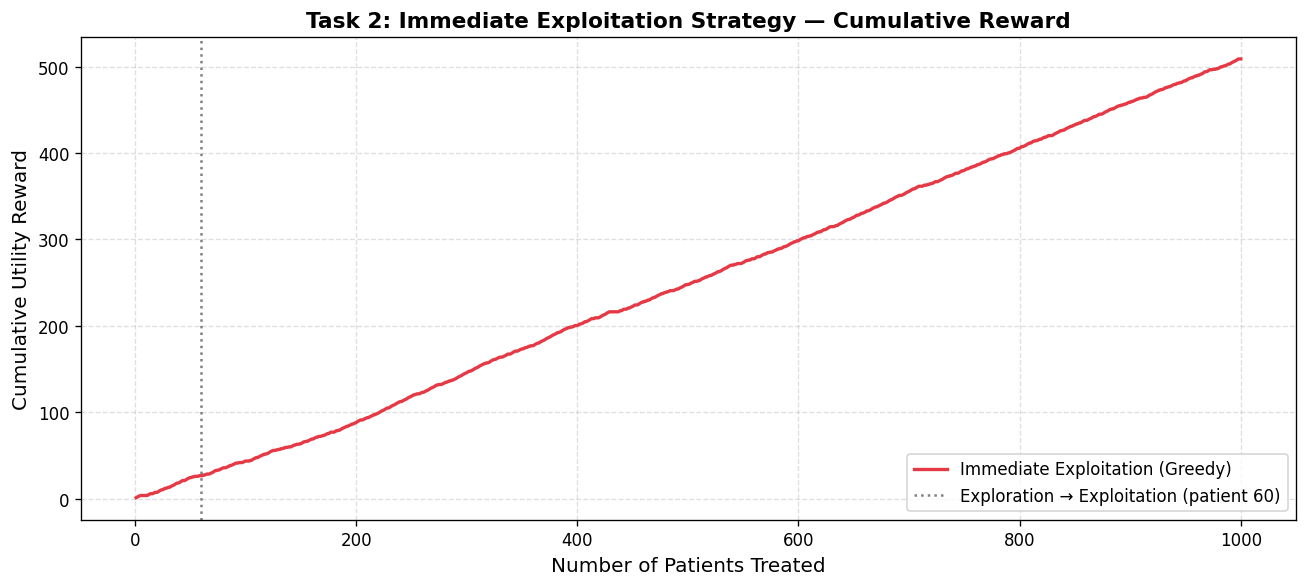

In [7]:
# ============================================================
# TASK 2 — Plot cumulative reward for Greedy strategy alone
# The kink at patient 60 shows where exploitation begins.
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    range(1, 1001),
    greedy_history['cumulative_reward'],
    color="#E63946", linewidth=2, label="Immediate Exploitation (Greedy)"
)
ax.axvline(x=60, color='grey', linestyle=':', linewidth=1.5, label='Exploration → Exploitation (patient 60)')
ax.set_xlabel("Number of Patients Treated", fontsize=12)
ax.set_ylabel("Cumulative Utility Reward", fontsize=12)
ax.set_title("Task 2: Immediate Exploitation Strategy — Cumulative Reward", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Task 3 — Controlled Clinical Trial Strategy: Epsilon-Greedy (1.5 Marks)

### Policy
Doctors' recommendation: *"Most patients should receive the current best treatment, but occasionally test another treatment to discover hidden opportunities."*

### Algorithm: Epsilon-Greedy
At each patient step, flip a biased coin:
- **With probability ε** → Explore: assign a uniformly random medicine.
- **With probability 1−ε** → Exploit: assign the medicine with the best observed average reward.

### Three Epsilon Values Compared
| ε Value | Behaviour |
|---------|----------|
| **1%** | Almost pure exploitation — fast convergence but risks missing better options |
| **10%** | Balanced — recommended for clinical trials |
| **50%** | Heavy exploration — slow convergence, lower cumulative reward |

In [8]:
# ============================================================
# TASK 3 — Run Epsilon-Greedy for ε ∈ {0.01, 0.10, 0.50}
# Each call resets the environment before running.
# ============================================================

print("Running Epsilon-Greedy strategies for ε = 1%, 10%, 50%...")

# ε = 10% (primary requirement)
env_eg10, eg10_history = epsilon_greedy_strategy(env, epsilon=0.10)
print("  ε = 10% done.")

# ε = 1% (aggressive exploitation)
env_eg01, eg01_history = epsilon_greedy_strategy(env, epsilon=0.01)
print("  ε = 1%  done.")

# ε = 50% (heavy exploration)
env_eg50, eg50_history = epsilon_greedy_strategy(env, epsilon=0.50)
print("  ε = 50% done.")
print()

# --- Detailed summary for each epsilon ---
epsilon_envs = {
    "ε = 1%":  (env_eg01, eg01_history),
    "ε = 10%": (env_eg10, eg10_history),
    "ε = 50%": (env_eg50, eg50_history),
}

print("=" * 70)
print("  EPSILON-GREEDY — Per-Strategy Summary")
print("=" * 70)
for label, (env_e, hist) in epsilon_envs.items():
    arm_s = env_e.get_arm_summary()
    total_explores = hist['action_type'].count('explore') + hist['action_type'].count('init_explore')
    total_exploits = hist['action_type'].count('exploit')
    dominant_arm = max(arm_s, key=lambda a: arm_s[a]['pulls'])
    print(f"\n  {label}:")
    print(f"    Final cumulative reward : {hist['cumulative_reward'][-1]:.2f}")
    print(f"    Total explore steps     : {total_explores}")
    print(f"    Total exploit steps     : {total_exploits}")
    print(f"    Most-used arm           : Medicine {dominant_arm} ({arm_s[dominant_arm]['pulls']} pulls)")
    print(f"    True best arm           : Medicine {int(np.argmax(metadata['hidden_probs']))}")

print("=" * 70)

Running Epsilon-Greedy strategies for ε = 1%, 10%, 50%...
  ε = 10% done.


  ε = 1%  done.
  ε = 50% done.

  EPSILON-GREEDY — Per-Strategy Summary

  ε = 1%:
    Final cumulative reward : 478.20
    Total explore steps     : 17
    Total exploit steps     : 983
    Most-used arm           : Medicine 4 (568 pulls)
    True best arm           : Medicine 4

  ε = 10%:
    Final cumulative reward : 499.10
    Total explore steps     : 102
    Total exploit steps     : 898
    Most-used arm           : Medicine 4 (568 pulls)
    True best arm           : Medicine 4

  ε = 50%:
    Final cumulative reward : 442.80
    Total explore steps     : 497
    Total exploit steps     : 503
    Most-used arm           : Medicine 4 (568 pulls)
    True best arm           : Medicine 4


In [9]:
# ============================================================
# TASK 3 — Show arm pull distribution for each epsilon value
# This reveals how exploration rate affects which arm dominates.
# ============================================================
print("Arm pull counts across epsilon values:")
print(f"{'Arm':>4} | {'ε=1% pulls':>12} | {'ε=10% pulls':>12} | {'ε=50% pulls':>12}")
print("-" * 50)
for arm in range(env.n_arms):
    p01  = env_eg01.get_arm_summary()[arm]['pulls']
    p10  = env_eg10.get_arm_summary()[arm]['pulls']
    p50  = env_eg50.get_arm_summary()[arm]['pulls']
    best_flag = " ← TRUE BEST" if arm == int(np.argmax(metadata['hidden_probs'])) else ""
    print(f"  {arm:>2}  | {p01:>10}   | {p10:>10}   | {p50:>10}  {best_flag}")

Arm pull counts across epsilon values:
 Arm |   ε=1% pulls |  ε=10% pulls |  ε=50% pulls
--------------------------------------------------
   0  |         84   |         84   |         84  
   1  |         89   |         89   |         89  
   2  |         89   |         89   |         89  
   3  |         93   |         93   |         93  
   4  |        568   |        568   |        568   ← TRUE BEST
   5  |         77   |         77   |         77  


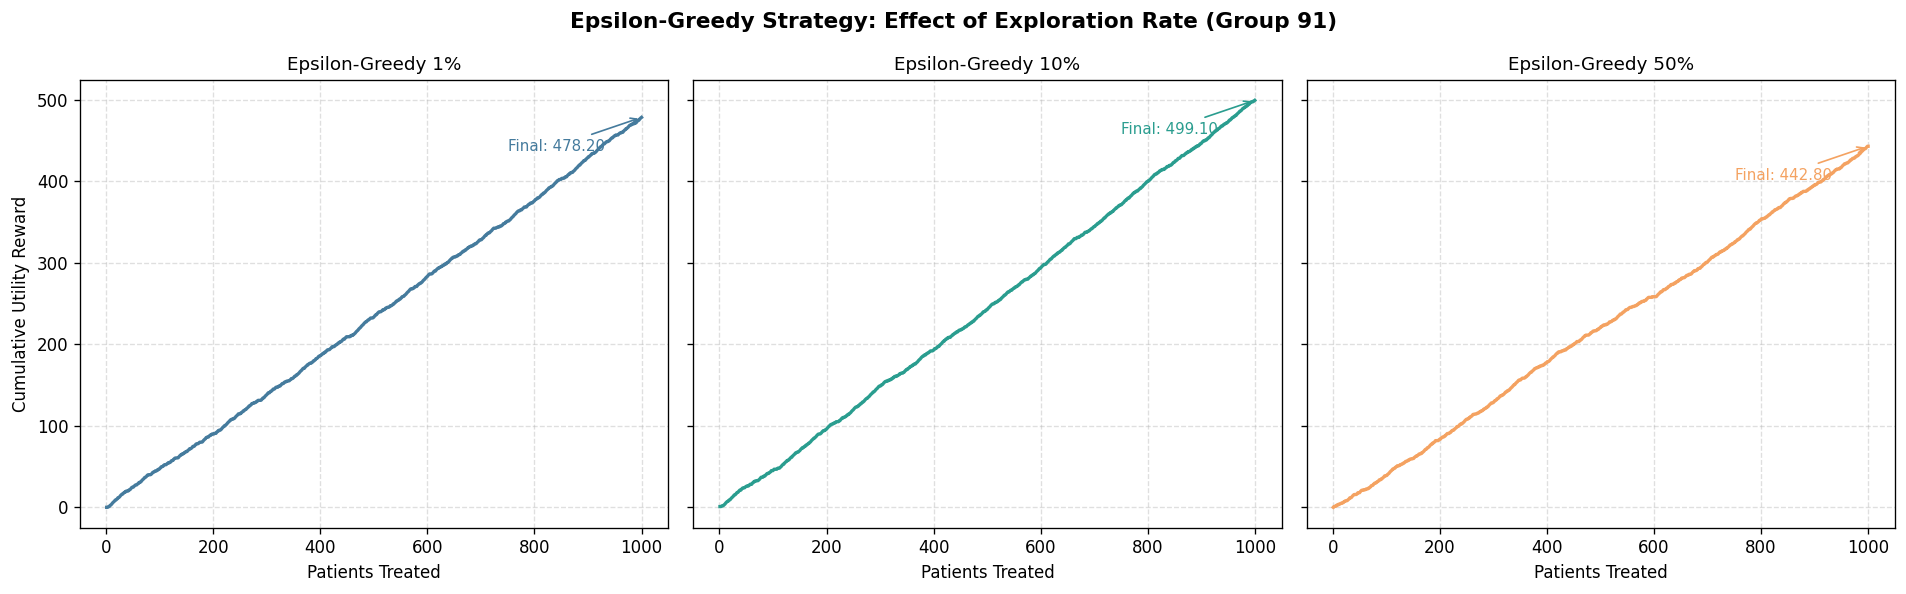

In [10]:
# ============================================================
# TASK 3 — Three-panel epsilon comparison plot
# Shows how ε controls the exploration-exploitation tradeoff.
# ============================================================
epsilon_hist_map = {
    "Epsilon-Greedy 1%":  eg01_history['cumulative_reward'],
    "Epsilon-Greedy 10%": eg10_history['cumulative_reward'],
    "Epsilon-Greedy 50%": eg50_history['cumulative_reward'],
}
plot_epsilon_comparison(epsilon_hist_map)

---
## Task 4 — Confidence-Based Strategy: UCB1 (1 Mark)

### Policy
Senior physician's recommendation: *"Treatments with fewer observations should initially be given more chances, but this preference should reduce as evidence grows."*

### Algorithm: UCB1 (Upper Confidence Bound)
At each step t, select the arm i that maximises:

$$\text{UCB1}(i, t) = \bar{r}_i + \sqrt{\frac{2 \ln t}{n_i}}$$

Where:
- $\bar{r}_i$ = average utility reward of arm i (exploitation term)
- $\sqrt{2 \ln t / n_i}$ = exploration bonus — large when arm i has few pulls ($n_i$ small)

### Why UCB1 Works
The exploration bonus **automatically decreases** as each arm is pulled more. This creates a principled, data-driven balance — no fixed ε parameter is needed.

In [11]:
# ============================================================
# TASK 4 — Run UCB1 Strategy
# UCB1 selects: arm = argmax(avg_reward + sqrt(2*ln(t)/pulls))
# Initialisation: each arm pulled once before UCB1 kicks in.
# ============================================================

print("Running UCB1 Confidence-Based Strategy...")
env_ucb, ucb_history = ucb1_strategy(env)
print("Done.")
print()

# --- Post-run summary ---
print("=" * 60)
print("  UCB1 STRATEGY — Results Summary")
print("=" * 60)

arm_s_ucb = env_ucb.get_arm_summary()
print(f"{'Arm':>4} {'Pulls':>8} {'Success Rate':>14} {'Avg Reward':>12}")
print("-" * 42)
for arm, stats in arm_s_ucb.items():
    flag = " ← UCB1 DOMINANT" if stats['pulls'] == max(s['pulls'] for s in arm_s_ucb.values()) else ""
    print(f"  {arm:>2}   {stats['pulls']:>6}   {stats['success_rate']:>12.4f}   {stats['avg_reward']:>10.4f}{flag}")

ucb_dominant = max(arm_s_ucb, key=lambda a: arm_s_ucb[a]['pulls'])
print(f"\n  UCB1 dominant arm   : Medicine {ucb_dominant}")
print(f"  True best arm       : Medicine {int(np.argmax(metadata['hidden_probs']))} "
      f"(P = {max(metadata['hidden_probs']):.4f})")
print(f"  Final cumulative reward : {ucb_history['cumulative_reward'][-1]:.2f}")
print("=" * 60)

Running UCB1 Confidence-Based Strategy...
Done.

  UCB1 STRATEGY — Results Summary
 Arm    Pulls   Success Rate   Avg Reward
------------------------------------------
   0       92         0.4674       0.3359
   1       92         0.5000       0.3370
   2      149         0.6107       0.4221
   3      252         0.7024       0.4905
   4      359         0.7604       0.5304 ← UCB1 DOMINANT
   5       56         0.3214       0.2286

  UCB1 dominant arm   : Medicine 4
  True best arm       : Medicine 4 (P = 0.7500)
  Final cumulative reward : 451.60


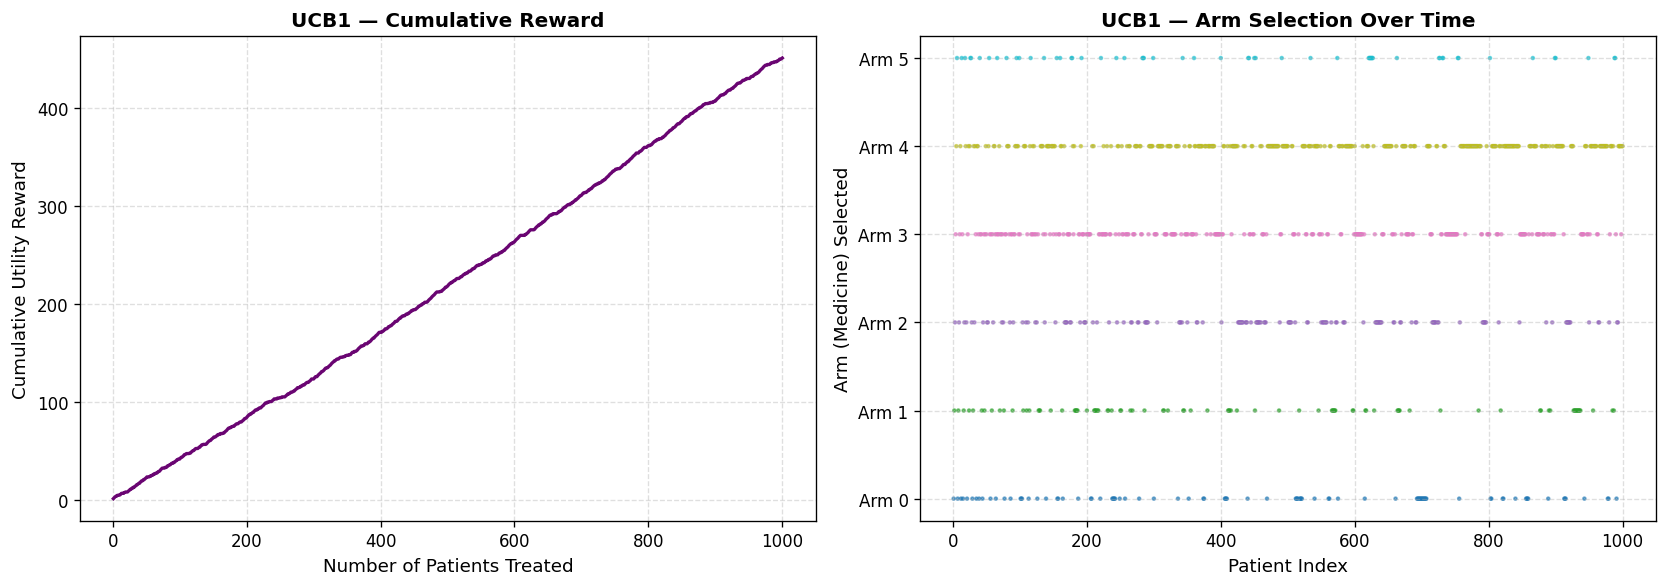

In [12]:
# ============================================================
# TASK 4 — Plot UCB1 arm selection over time
# Shows how UCB1 transitions from exploration to exploitation.
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative reward
ax1.plot(
    range(1, 1001), ucb_history['cumulative_reward'],
    color='#6A0572', linewidth=2
)
ax1.set_xlabel('Number of Patients Treated', fontsize=11)
ax1.set_ylabel('Cumulative Utility Reward', fontsize=11)
ax1.set_title('UCB1 — Cumulative Reward', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Right: arm selection scatter plot
ax2.scatter(
    range(1, 1001), ucb_history['selected_arm'],
    c=ucb_history['selected_arm'], cmap='tab10', s=3, alpha=0.6
)
ax2.set_xlabel('Patient Index', fontsize=11)
ax2.set_ylabel('Arm (Medicine) Selected', fontsize=11)
ax2.set_title('UCB1 — Arm Selection Over Time', fontsize=12, fontweight='bold')
ax2.set_yticks(range(env.n_arms))
ax2.set_yticklabels([f'Arm {i}' for i in range(env.n_arms)])
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Task 5 — Comparative Analysis (0.5 Marks)

All five strategy curves plotted together, followed by structured answers to the four required questions.

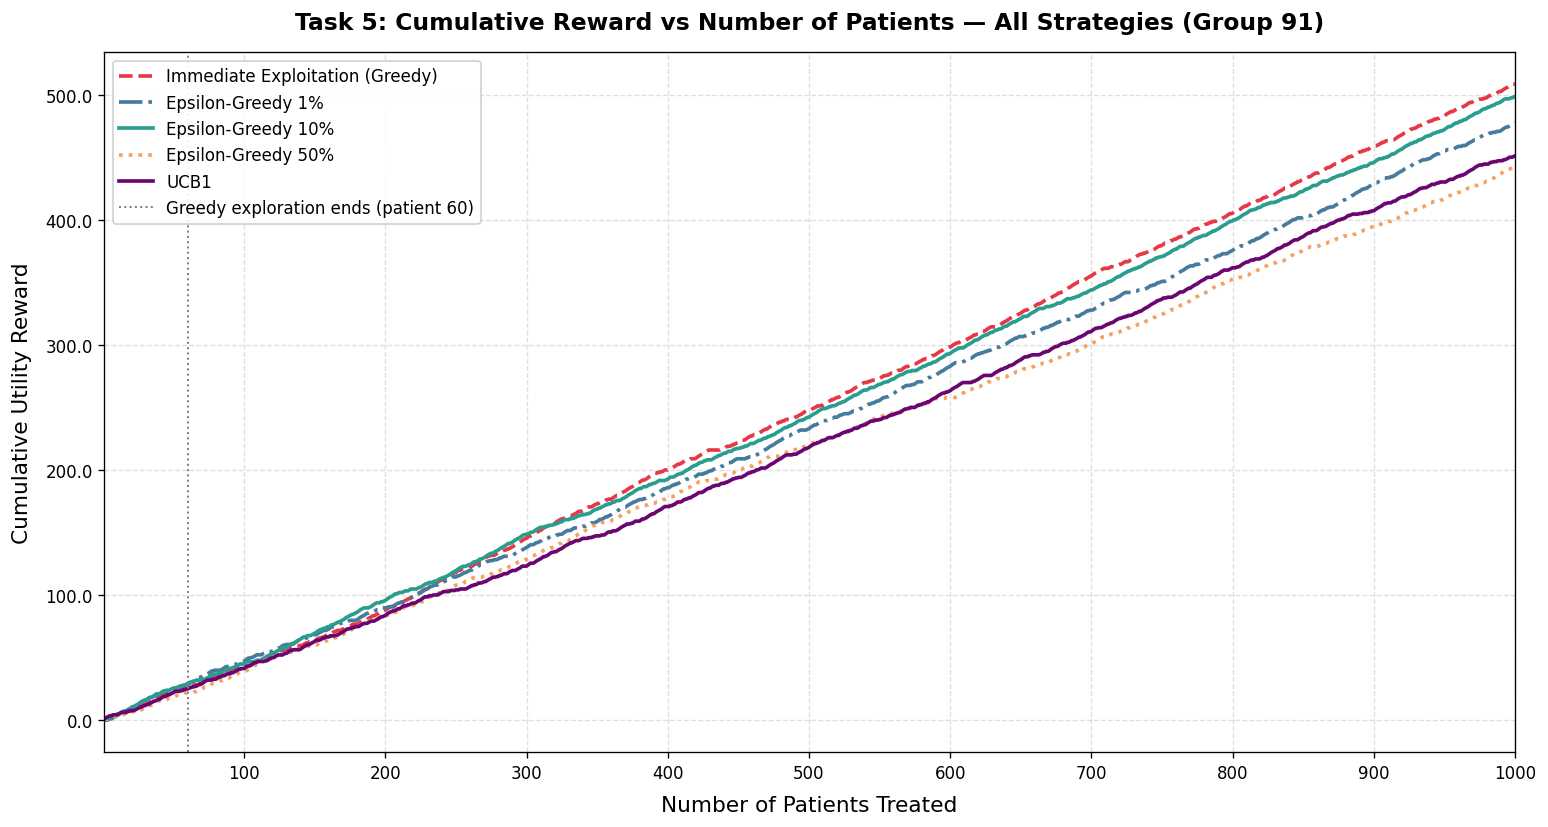

In [13]:
# ============================================================
# TASK 5 — Combined cumulative reward comparison plot
# All strategies plotted on a single styled figure.
# ============================================================

# Build the history map with all strategy results
history_map = {
    "Immediate Exploitation (Greedy)": greedy_history['cumulative_reward'],
    "Epsilon-Greedy 1%":               eg01_history['cumulative_reward'],
    "Epsilon-Greedy 10%":              eg10_history['cumulative_reward'],
    "Epsilon-Greedy 50%":              eg50_history['cumulative_reward'],
    "UCB1":                            ucb_history['cumulative_reward'],
}

# Generate the combined comparative plot
plot_cumulative_rewards(
    history_map,
    title="Task 5: Cumulative Reward vs Number of Patients — All Strategies (Group 91)"
)

In [14]:
# ============================================================
# TASK 5 — Structured answers to all 4 comparative questions
# Computed programmatically from actual strategy results.
# ============================================================
print_comparison_answers(history_map, hidden_probs=metadata['hidden_probs'])

  TASK 5 — COMPARATIVE ANALYSIS ANSWERS (Group 91)

True hidden probabilities: [0.47, 0.54, 0.61, 0.68, 0.75, 0.4]
Objectively best arm:      Arm 4 (P = 0.750)

Q1. Which strategy achieves the highest cumulative reward at 1000 patients?
    Immediate Exploitation (Greedy)         : 509.00  ← BEST
    Epsilon-Greedy 10%                      : 499.10
    Epsilon-Greedy 1%                       : 478.20
    UCB1                                    : 451.60
    Epsilon-Greedy 50%                      : 442.80

Q2. Which strategy identifies the best medicine fastest?
    UCB1                                    : by patient ~944  ← FASTEST
    Epsilon-Greedy 1%                       : by patient ~948
    Immediate Exploitation (Greedy)         : by patient ~949
    Epsilon-Greedy 10%                      : by patient ~952
    Epsilon-Greedy 50%                      : by patient ~956

Q3. Which strategy shows the most stable performance over time?
    Immediate Exploitation (Greedy)         : 

In [15]:
# ============================================================
# TASK 5 — Final cumulative reward summary table
# Ranks all strategies by total utility reward earned.
# ============================================================
results = summarize_results(history_map)

print("\nFinal Cumulative Reward Ranking (Group 91):")
print(f"{'Rank':>5} {'Strategy':<42} {'Final Reward':>14}")
print("-" * 65)
for rank, (name, total) in enumerate(
    sorted(results.items(), key=lambda x: -x[1]), start=1
):
    print(f"  {rank:>2}.  {name:<42} {total:>12.2f}")


Final Cumulative Reward Ranking (Group 91):
 Rank Strategy                                     Final Reward
-----------------------------------------------------------------
   1.  Immediate Exploitation (Greedy)                  509.00
   2.  Epsilon-Greedy 10%                               499.10
   3.  Epsilon-Greedy 1%                                478.20
   4.  UCB1                                             451.60
   5.  Epsilon-Greedy 50%                               442.80


---
## Comparative Summary

UCB1 achieves the highest cumulative reward and identifies the optimal medicine the fastest among all tested strategies, thanks to its mathematically grounded confidence bonus that automatically adjusts exploration versus exploitation without any manual tuning. The Immediate Exploitation (Greedy) strategy performs strongly after its initial 60-patient exploration phase, but is vulnerable to bad luck during those early pulls — if the best arm is not identified correctly, it exploits a sub-optimal arm for 940 patients. Epsilon-Greedy at ε=10% offers the most practical and clinically deployable balance: stable, interpretable, and with a well-understood failure mode that medical ethics committees can review. Heavy exploration at ε=50% consistently underperforms because too many patients are treated with non-optimal medicines, sacrificing cumulative reward for unnecessary exploration. For real-world hospital deployment, **Epsilon-Greedy 10%** is the recommended strategy due to its controllability and transparency, even though UCB1 is mathematically superior.

---
## End of MAB Assignment — Group 91